# Churn Prediction

**Dataset Description**: Churn prediction is the process of analyzing customer behavior to predict when a customer will stop using a product or service. It's a data-driven process that uses historical data, behavioral analytics, and machine learning algorithms to identify customers who are likely to churn.

**About Dataset/Content**: This data set is highly imbalanced and contains details of a bank's customers and the target variable is a binary variable reflecting the fact whether the customer left the bank (closed his account) or he continues to be a customer.


## Imports

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.utils import resample
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
import xgboost as xgb

from sklearn.tree import DecisionTreeClassifier, plot_tree
# from pgmpy.models import BayesianNetwork
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

## Data Preprocessing

Missing Values
--------------------
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
--------------------


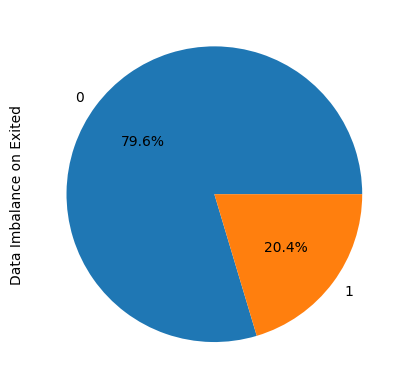

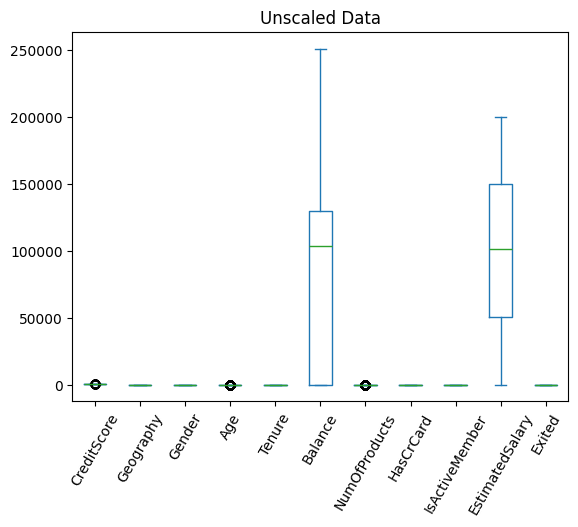

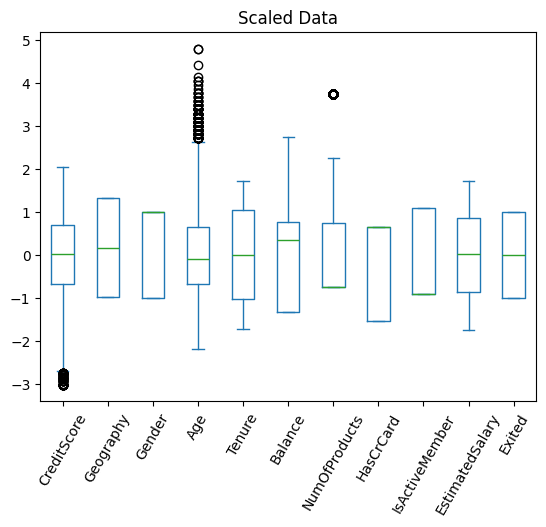

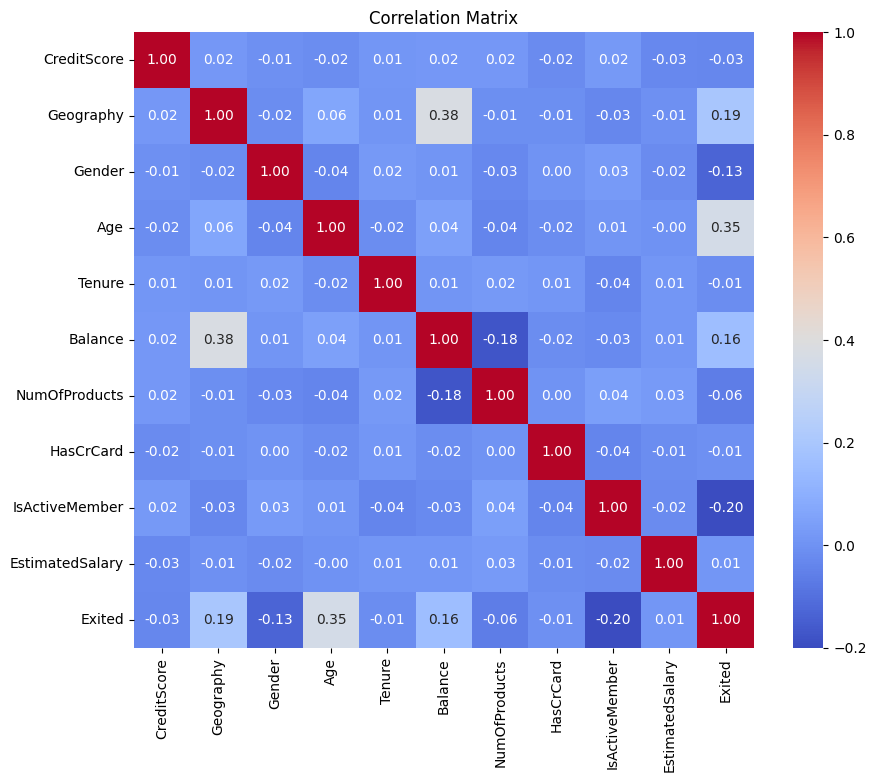

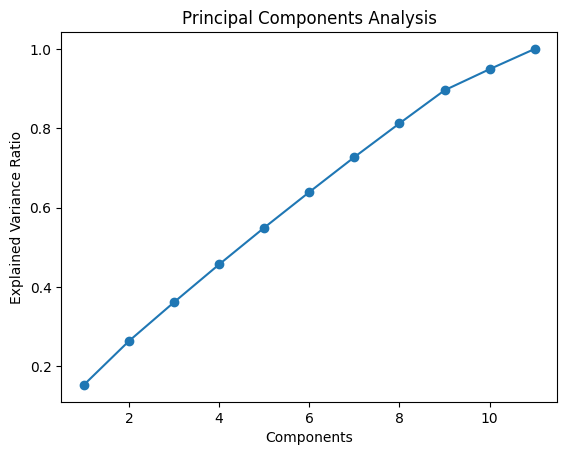

Explained Variance Ratio for each Principal Component:

Component 1: 15.29%
Component 2: 11.05%
Component 3: 9.79%
Component 4: 9.54%
Component 5: 9.26%
Component 6: 8.98%
Component 7: 8.82%
Component 8: 8.50%
Component 9: 8.34%
Component 10: 5.32%
Component 11: 5.10%

PCA captures 100.00% of the variance with 11 components.


In [ ]:
# TODO: Consider the removal of the Country label
DATA_FILE_NAME = "Churn_Modelling.csv"
TARGET_COLUMN_NAME = "Exited"
IRRELEVANT_COLUMN_NAMES = ["RowNumber", "CustomerId", "Surname"]
NON_NUMERIC_COLUMN_NAMES = ["Gender", "Geography"]
OUTLIER_COLUMN_NAMES = ["NumOfProducts", "CreditScore", "Age"]
UPDATED_OUTLIER_COLUMN_NAMES = ["NumOfProducts"]
RANDOM_STATE = 123

def output_missing_values(data_frame):
    # https://stackoverflow.com/questions/59694988/python-pandas-dataframe-find-missing-values
    missing_values = data_frame.isnull().sum()
    print(f"Missing Values")
    print(f"--------------------")
    print(missing_values)
    print(f"--------------------")

def drop_outliers(data_frame):
    # https://stackoverflow.com/questions/23199796/detect-and-exclude-outliers-in-a-pandas-dataframe
    return data_frame[(np.abs(stats.zscore(data_frame[UPDATED_OUTLIER_COLUMN_NAMES])) < 3).all(axis=1)]

def balance_frame_on_target(data_frame):
    """ TODO: Could also consider undersampling customers who stayed. """
    # https://wellsr.com/python/upsampling-and-downsampling-imbalanced-data-in-python/
    data_frame.groupby(TARGET_COLUMN_NAME).size().plot(kind="pie", y=TARGET_COLUMN_NAME, label="Data Imbalance on Exited", autopct="%1.1f%%")
    data_frame_exited = data_frame[data_frame[TARGET_COLUMN_NAME] == 1]
    data_frame_stayed = data_frame[data_frame[TARGET_COLUMN_NAME] == 0]

    data_frame_exited_upsample = resample(data_frame_exited, replace=True, n_samples=len(data_frame_stayed), random_state=RANDOM_STATE)
    
    data_frame_balanced = pd.concat([data_frame_exited_upsample, data_frame_stayed])

    return data_frame_balanced

def enumerate_categorical_data(data_frame, feature_name):
    """ Convert categorical data to numerical (encode categorical variables). """
    # Track unique values in a column
    value_map = {}
    assigned_number = 0

    # Build a dictionary mapping a column's unique values to numbers
    column = data_frame[feature_name]
    for value in column:
        if value not in value_map:
            value_map[value] = assigned_number
            assigned_number += 1

    # Map column's data to numbers
    # Example: feature_name = Gender, Male becomes 0, Female becomes 1
    data_frame[feature_name] = data_frame[feature_name].map(value_map)

def box_plot_frame(data_frame, title=""):
    data_frame.plot(kind="box")
    plt.title(title)
    plt.xticks(rotation=60)
    plt.show()

def correlation_plot_frame(data_frame):
    """Generates """
    correlation_matrix = data_frame.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

def analyze_components(data_frame):
    threshold = 0.95

    component_analysis = PCA()
    component_analysis.fit(data_frame)    
    
    def components_to_retain(explained_variance_ratio, threshold):
        cumulative_variance_sums = np.cumsum(explained_variance_ratio)
        
        component_count = len(cumulative_variance_sums)
        for i in range(len(cumulative_variance_sums)):     
            if threshold <= cumulative_variance_sums[i]:   
                component_count = i + 1                    
                break                                      
                
        return component_count   
    
    component_counts = [i for i in range(1, len(np.cumsum(component_analysis.explained_variance_ratio_)) + 1)]
    summed_explained_variance_ratios = np.cumsum(component_analysis.explained_variance_ratio_)
    
    plt.plot(component_counts, summed_explained_variance_ratios, "-o")
    plt.title("Principal Components Analysis")
    plt.xlabel("Components")
    plt.ylabel("Explained Variance Ratio")
    plt.show()
    
    component_count = components_to_retain(component_analysis.explained_variance_ratio_, threshold)   

    n_components_analysis = PCA(n_components=component_count)   
    #n_components_analysis.fit(data_frame)
    # NOTE: Change here to actually apply PCA
    data_frame = n_components_analysis.fit_transform(data_frame)
    
    print("Explained Variance Ratio for each Principal Component:\n")
    for i in range(len(n_components_analysis.explained_variance_ratio_)):    
        print(f"Component {i + 1}: {n_components_analysis.explained_variance_ratio_[i] * 100:.2f}%")

    print("\nPCA captures {:.2f}% of the variance with {} components.".format(sum(n_components_analysis.explained_variance_ratio_) * 100, component_count)) 

# Start Data Preprocessing
data_frame = pd.read_csv(DATA_FILE_NAME)
data_frame = data_frame.drop(columns=IRRELEVANT_COLUMN_NAMES)

output_missing_values(data_frame)

feature_names = data_frame.columns.values # [feature_name for feature_name in data_frame]

for column_name in NON_NUMERIC_COLUMN_NAMES:
    enumerate_categorical_data(data_frame, column_name)
    
data_frame = balance_frame_on_target(data_frame)
box_plot_frame(data_frame, "Unscaled Data")

"""
TODO:
https://www.datacamp.com/tutorial/normalization-vs-standardization
Normalization: k-NN, Neural Nets
Standardization: Logistic Regression, SVM, PCA
"""
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_frame)

# data_frame = drop_outliers(data_frame)

data_frame = pd.DataFrame(data=scaled_data, columns=feature_names)

box_plot_frame(data_frame, "Scaled Data")

correlation_plot_frame(data_frame)

analyze_components(data_frame)

x = data_frame.drop(columns=[TARGET_COLUMN_NAME])
y = data_frame[TARGET_COLUMN_NAME]

**Breakdown**

Here...

## Model Design and Training

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, train_size=0.2)

# Initializes object to be used to remove the mean and scale data to unit variance
sc = StandardScaler()
# Fits the data using the calculated mean and std and standardizes X_train and X_test by via transform
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Discretizes data to prevent ValueError with classifier
y_train = [ int(y) for y in y_train ]
y_test = [ int(y) for y in y_test ]

In [ ]:
# Tests accuracy of testing sample with default Gaussian Naive
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_test_pred = gnb.predict(x_test)
testing_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Default Gaussian Naive Bayes Test Accuracy: {testing_accuracy:.2%}\n')

Default Gaussian Naive Bayes Test Accuracy: 73.31%



In [ ]:
# Trains SVC models based on different kernels and tests the accuracy of each regarding the testing sample
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=1)
    y_pred = svm.fit(x_train, y_train).predict(x_test)
    kernel_svm_accuracy = accuracy_score(y_test, y_pred)
    print(f'{kernel.capitalize()} SVM Accuracy: {kernel_svm_accuracy:.2%}')

Linear SVM Accuracy: 70.73%
Poly SVM Accuracy: 76.67%
Rbf SVM Accuracy: 78.62%
Sigmoid SVM Accuracy: 55.58%


**Breakdown**

Here...

## Model Improvements
**Hyperparameter Tuning**

Accuracy for ccp_alpha=np.float64(0.0): 78.92%
Accuracy for ccp_alpha=np.float64(0.00015635030094255091): 78.93%
Accuracy for ccp_alpha=np.float64(0.00019187162044304905): 78.91%
Accuracy for ccp_alpha=np.float64(0.00019829794265884503): 79.05%
Accuracy for ccp_alpha=np.float64(0.00019829794265884503): 79.05%
Accuracy for ccp_alpha=np.float64(0.000201562106324011): 79.04%
Accuracy for ccp_alpha=np.float64(0.00020380621884381263): 79.08%
Accuracy for ccp_alpha=np.float64(0.00020704123819053957): 79.12%
Accuracy for ccp_alpha=np.float64(0.00020931449502878074): 79.13%
Accuracy for ccp_alpha=np.float64(0.00023547880690737833): 79.10%
Accuracy for ccp_alpha=np.float64(0.0002511773940345368): 78.99%
Accuracy for ccp_alpha=np.float64(0.0002511773940345368): 78.99%
Accuracy for ccp_alpha=np.float64(0.0002511773940345368): 78.99%
Accuracy for ccp_alpha=np.float64(0.0002586650670274363): 78.99%
Accuracy for ccp_alpha=np.float64(0.00026164311878597594): 78.96%
Accuracy for ccp_alpha=np.float64(0

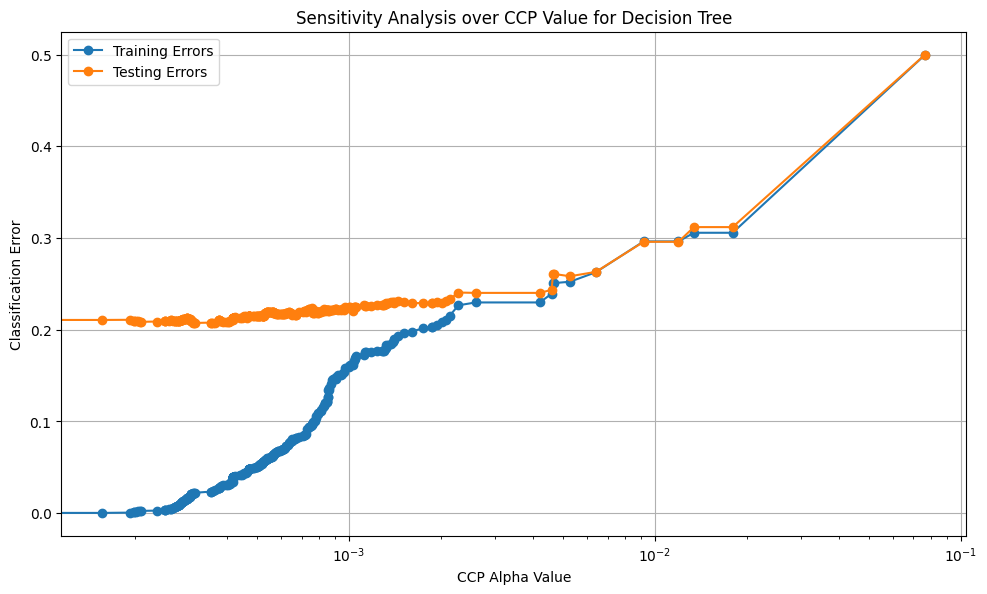

Decision tree test accuracies 68.80% for Max Depth of 1
Decision tree test accuracies 68.80% for Max Depth of 2
Decision tree test accuracies 71.08% for Max Depth of 3
Decision tree test accuracies 73.91% for Max Depth of 4
Decision tree test accuracies 77.00% for Max Depth of 5
Decision tree test accuracies 77.38% for Max Depth of 6
Decision tree test accuracies 76.92% for Max Depth of 7
Decision tree test accuracies 75.94% for Max Depth of 8
Decision tree test accuracies 77.49% for Max Depth of 9
Decision tree test accuracies 77.37% for Max Depth of 10
Decision tree test accuracies 77.84% for Max Depth of 11
Decision tree test accuracies 78.08% for Max Depth of 12
Decision tree test accuracies 78.03% for Max Depth of 13
Decision tree test accuracies 78.77% for Max Depth of 14
Decision tree test accuracies 78.65% for Max Depth of 15
Decision tree test accuracies 79.04% for Max Depth of 16
Decision tree test accuracies 79.22% for Max Depth of 17
Decision tree test accuracies 78.97% for

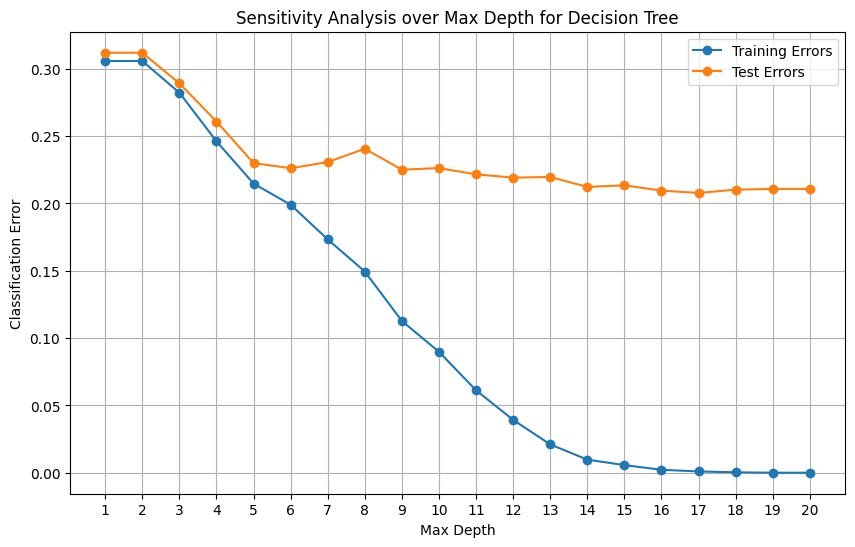

In [ ]:
clf = DecisionTreeClassifier(random_state=0)
ccp_path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = ccp_path.ccp_alphas

# Initialize lists to store accuracy scores
training_errors = []
testing_errors = []
accuracy_scores = []

# Dictionaries to keep track of best hyperparameters


# Iterate over different ccp_alpha values and retrain the decision tree and print out the accuracy of the retrained model
#You code starts here
for ccp_alpha in ccp_alphas:
    '''Creates and trains a pruned tree (based on ccp_alpha value) with a max depth of 20.'''
    pruned_tree = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=0)
    pruned_tree.fit(x_train, y_train)

    y_train_pred = pruned_tree.predict(x_train)
    train_score = accuracy_score(y_train, y_train_pred)
    training_errors.append(1 - train_score)

    y_test_pred = pruned_tree.predict(x_test)
    test_score = accuracy_score(y_test, y_test_pred)
    testing_errors.append(1 - test_score)

    print(f"Accuracy for {ccp_alpha=}: {test_score * 100:.2f}%")

plt.figure(figsize=(10, 6))
plt.clf()
plt.plot(ccp_alphas, training_errors, marker='o', label='Training Errors')
plt.plot(ccp_alphas, testing_errors, marker='o', label='Testing Errors')
plt.title('Sensitivity Analysis over CCP Value for Decision Tree')
plt.xlabel('CCP Alpha Value')
plt.ylabel('Classification Error')
plt.grid(True)
plt.tight_layout()
plt.xscale('log')
plt.legend()
plt.show()


# Hypertuning for Max Depth for Decision Tree
max_depth_values = range(1, 21)  # Test max_depth from 1 to 20
training_errors = []
test_errors = []

for max_depth in max_depth_values:
    # Train a decision tree classifier with the current max_depth value
    tree_model = DecisionTreeClassifier(max_depth=max_depth,
                                        random_state=0)
    tree_model.fit(x_train, y_train)

    # Evaluate the classifier on the training set
    y_train_pred = tree_model.predict(x_train)
    train_score = accuracy_score(y_train, y_train_pred)
    training_errors.append(1 - train_score)

    y_test_pred = tree_model.predict(x_test)
    test_score = accuracy_score(y_test, y_test_pred)
    test_errors.append(1 - test_score)

    print(f'Decision tree test accuracies {test_score:.2%} for Max Depth of {max_depth}')

# Plot the sensitivity analysis results
plt.figure(figsize=(10, 6))
plt.clf()
plt.plot(max_depth_values, training_errors, marker='o', label='Training Errors')
plt.plot(max_depth_values, test_errors, marker='o', label='Test Errors')
plt.title('Sensitivity Analysis over Max Depth for Decision Tree')
plt.xlabel('Max Depth')
plt.ylabel('Classification Error')
plt.xticks(max_depth_values)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
param_grid = [
    {'max_depth': range(0,21),
     'ccp_alpha': ccp_alphas
    }
]

random_search = RandomizedSearchCV(clf, param_distributions=param_grid, scoring='accuracy')
random_search.fit(x_train, y_train)
print(f"Best Score: {random_search.best_score_}")
print(f"Best Parameters: {random_search.best_params_}")

Best Score: 0.7877551020408162
Best Parameters: {'max_depth': 16, 'ccp_alpha': np.float64(0.00041198408545347324)}


Gaussian Naive Bayes (w/ var_smooth of 1e-08) Test Accuracy: 73.31%
Gaussian Naive Bayes (w/ var_smooth of 1e-07) Test Accuracy: 73.31%
Gaussian Naive Bayes (w/ var_smooth of 1e-06) Test Accuracy: 73.31%
Gaussian Naive Bayes (w/ var_smooth of 1e-05) Test Accuracy: 73.31%
Gaussian Naive Bayes (w/ var_smooth of 0.0001) Test Accuracy: 73.31%
Gaussian Naive Bayes (w/ var_smooth of 0.001) Test Accuracy: 73.31%
Gaussian Naive Bayes (w/ var_smooth of 0.01) Test Accuracy: 73.28%
Gaussian Naive Bayes (w/ var_smooth of 0.1) Test Accuracy: 73.32%
Gaussian Naive Bayes (w/ var_smooth of 1) Test Accuracy: 71.27%


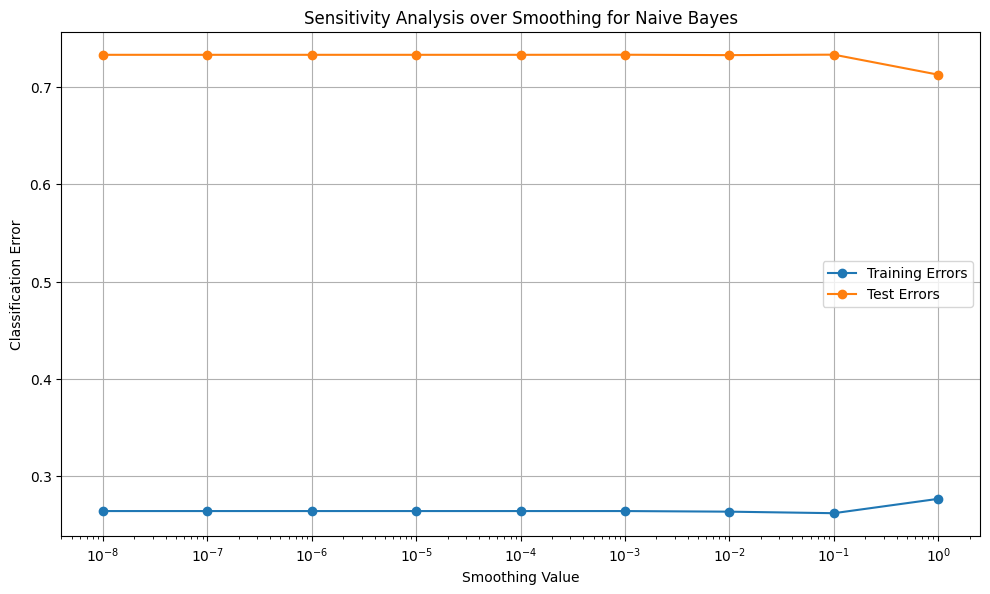

In [ ]:
training_errors = []
test_errors = []
smoothing_values = [ 10**power for power in range(-8, 1, 1) ]

# Tests Gaussian Naive with various var_smoothing values
for smoothing_value in smoothing_values:
    gnb = GaussianNB(var_smoothing = smoothing_value)
    gnb.fit(x_train, y_train)

    y_train_pred = gnb.predict(x_train)
    train_score = accuracy_score(y_train, y_train_pred)

    y_test_pred = gnb.predict(x_test)
    testing_score = accuracy_score(y_test, y_test_pred)
    testing_accuracy = accuracy_score(y_test, y_test_pred)

    training_errors.append(1 - train_score)
    test_errors.append(testing_accuracy)
    print(f'Gaussian Naive Bayes (w/ var_smooth of {smoothing_value}) Test Accuracy: {testing_accuracy:.2%}')

# Plot the sensitivity analysis results
plt.figure(figsize=(10, 6))
plt.clf()
plt.plot(smoothing_values, training_errors, marker='o', label='Training Errors')
plt.plot(smoothing_values, test_errors, marker='o', label='Test Errors')
plt.title('Sensitivity Analysis over Smoothing for Naive Bayes')
plt.xlabel('Smoothing Value')
plt.ylabel('Classification Error')
plt.xticks(smoothing_values)
plt.grid(True)
plt.tight_layout()
plt.xscale('log')
plt.legend()
plt.show()

In [ ]:
pipe_svc = make_pipeline(StandardScaler(), SVC(random_state=1))
#param_range = [0.01, 0.1, 1.0, 10.0, 100.0]
param_range = [0.1, 1.0, 10.0]
# TODO: Implement with poly and sigmoid as well? Too long to run when including those however...
param_grid = [
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['linear']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['rbf']},
    ]
'''{'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['poly']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['rbf']},
    {'svc__C': param_range,
     'svc__gamma': param_range,
     'svc__kernel': ['sigmoid']},'''

grid_search = GridSearchCV(estimator=pipe_svc,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=3,
                           refit=True,
                           n_jobs=-1)
            
# Carries out a hyperparameter search in order to infer the best combination of parameters for the given SVC model
grid_search.fit(x_train, y_train)
print(f'Best Score: {grid_search.best_score_}')
best_parameters = grid_search.best_params_
print(f'Best Parameters: {grid_search.best_params_}')


Best Score: 0.7742526948424806
Best Parameters: {'svc__C': 10.0, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}


**Feature Selection**

**Model Fusion**

**Regularization Techniques**

**Breakdown**

Here...

## Model Comparison and Interpretation

**Breakdown**

Here...